In [72]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [73]:
def load_data_all(dataset, s):
    print(dataset)
    preprocess_file = './data/'+dataset+'.pkl'
    full_M_file = './data/'+dataset+'/matrix.pt'
    if dataset == 'random':
        mat1 = torch.randn(100,1)
        mat2 = torch.randn(1, 5)
        matrix = mat1 @ mat2
        return mat1, mat2, matrix

    elif dataset == 'ml-1m':
        # read table
        ratings_title = ['UserID','MovieID', 'ratings', 'timestamps']
        ratings = pd.read_table(data_path+'ml-1m/ratings.dat', sep='::', header=None, names=ratings_title, engine = 'python')
        ratings = ratings.filter(regex='UserID|MovieID|ratings')

        # sample
        unique_ids = ratings['MovieID'].unique()
        selected_ids = np.random.choice(unique_ids, size=s, replace=False)
        selected_data = ratings[ratings['MovieID'].isin(selected_ids)]

        #selected_data = torch.tensor(selected_data.values)
        matrix_df = selected_data.pivot_table(index='UserID', columns='MovieID', values='ratings', aggfunc='first')
        matrix_df = matrix_df.fillna(0)
        matrix = torch.tensor(matrix_df.values)

        return matrix
    
    elif dataset == 'netflix':
        df = pd.read_csv(
            "./data/netflix/data.csv",
            names=["movie_id", "user_id", "rating", "date"],
            parse_dates=["date"],
            encoding="ISO-8859-1",
            engine="python",
        )
        data = df[["movie_id", "user_id", "rating"]]
        # sample
        unique_ids = data['movie_id'].unique()
        selected_ids = np.random.choice(unique_ids, size=s, replace=False)
        selected_data = data[data['movie_id'].isin(selected_ids)]

        #selected_data = torch.tensor(selected_data.values)
        matrix_df = selected_data.pivot_table(index='user_id', columns='movie_id', values='rating', aggfunc='first')
        matrix_df = matrix_df.fillna(0)
        matrix = torch.tensor(matrix_df.values)

        return matrix
    
    elif dataset == 'gene':
        M = load_data_gene()

mat1, mat2, M = load_data_all('random', s=150)

print(f"original user: {M.shape[0]} item: {M.shape[1]}")
M = M.float()

random
original user: 100 item: 5


In [128]:
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

In [120]:
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

def svd_norm(A):
    U, S, V = torch.svd(A)

    print(S.max())
    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [115]:
r = mat2.shape[0]
epochs = 500
alpha = 1
p = 0.05
noise = 0.01
dataset = 'random'

tensor([[-7.9698e-02,  8.4383e-01, -2.4343e-01,  ..., -4.2571e-02,
         -1.4358e-03,  2.2609e-02],
        [ 7.9840e-02,  1.0769e-02,  1.1308e-01,  ..., -2.1016e-01,
          1.4223e-02, -1.8467e-01],
        [-8.4304e-03, -2.0187e-04, -1.4924e-03,  ..., -2.2773e-01,
         -2.7757e-03,  1.0250e-01],
        ...,
        [ 1.2799e-01,  1.3518e-02, -3.0513e-01,  ...,  7.7783e-01,
         -1.0631e-04, -3.9960e-03],
        [-1.6331e-02, -1.2424e-03,  9.7962e-05,  ..., -2.7858e-03,
          9.9955e-01,  3.8813e-03],
        [ 1.5084e-01, -1.0195e-03,  4.8556e-02,  ...,  2.4762e-02,
          3.7015e-03,  9.5207e-01]])
tensor([1.0000e+00, 1.9109e-07, 5.8003e-08, 2.8017e-08, 1.1344e-08])
tensor([[-0.0427,  0.1371, -0.5487,  0.6244, -0.5371],
        [-0.0583, -0.0261, -0.7490, -0.6595, -0.0035],
        [ 0.0358,  0.2865,  0.3591, -0.4182, -0.7828],
        [ 0.3447, -0.8914,  0.0195, -0.0158, -0.2931],
        [-0.9353, -0.3222,  0.0926, -0.0092, -0.1133]])
tensor(0.9438)
norm of 

100%|██████████| 500/500 [00:01<00:00, 479.95it/s, In epoch 499, loss: 119.629)]


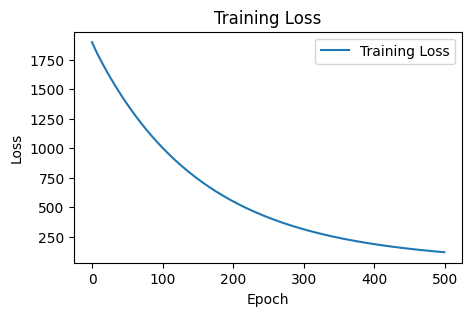

mat2: tensor([[-0.9009,  2.1512,  2.9841]])
tensor(1.0000)
tensor(112.5054, grad_fn=<MaxBackward1>)
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<LinalgVectorNormBackward0>)
tensor([[-0.2379,  0.5680,  0.7879]])
tensor(1.4427, grad_fn=<LinalgVectorNormBackward0>)
tensor(1.0000)


RuntimeError: The size of tensor a (5) must match the size of tensor b (3) at non-singleton dimension 1

In [144]:
u, d, v = torch.linalg.svd(M)
print(u)
print(d)
print(v)
# observed M & norm
mask = torch.bernoulli(torch.full((M.shape[0],), p)).bool()
observed_M = deepcopy(M)
observed_M[mask] = 0
observed_M_norm, scale_M = svd_norm(observed_M)
MTM = torch.mm(observed_M_norm.t(), observed_M_norm)
scale_diag = (p-1) / (p**2) * torch.diag(MTM).diag()
A = scale_diag + MTM

print(f"norm of M: {scale_M}")

# parameters
d1, d2 = observed_M.shape
X = torch.randn(d2, d2, requires_grad=True)
loop = tqdm(range(epochs))
eta = 1 / np.sqrt(epochs)
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean()
    U, D, Vt = torch.linalg.svd(X, full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2))

    X.grad = X.grad + alpha * U @ Vt + noise_matrix
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

print(f"mat2: {mat2}")
M, scale_M = svd_norm(M)
X, _ = svd_norm(X)

#X = svd_norm_reverse(X, scale_M)

u, d, v = top_r_svd(mat2, r)
ux, dx, vx = torch.linalg.svd(X)

m2 = v.t() @ v

#ux, dx, vx = torch.linalg.svd(X)
xx = vx.t() @ vx
xxx = ux @ dx.diag() @ vx
print(torch.norm(vx, p=2, dim=1))
print(v)
print(torch.norm(X))
print(torch.norm(M))
print((xx-m2))
print(xx.mean())
print(torch.allclose(xx, m2, atol=1e-03, rtol=1e-03))


In [ ]:
_, S, item_vector = top_r_svd(X, r)
predict_matrix = []
miss_item_u = []
for i in range(5):
    M_u = M[miss_users][i]
    non_zero_indices = M_u.nonzero(as_tuple=True)[0]
    observed_entries = non_zero_indices[:r]
    miss_entries = non_zero_indices[r:]
    miss_item_u.append(miss_entries.tolist())
    M_non_zero = M_u[observed_entries].unsqueeze(0)
    observed_item_vector = item_vector[observed_entries]

    # transpose (ATXT = BT <==> XA=B)
    
    #print(torch.det(observed_item_vector))
    #u = torch.linalg.lstsq(observed_item_vector, M_non_zero.t())[0].t()
    #u = u[:,:r]
    #print(torch.det(observed_item_vector))
    u = torch.linalg.solve(observed_item_vector, M_non_zero.t()).t()
    
    #u = constrain_opt(A=observed_item_vector, B=M_non_zero.t(), C=item_vector[miss_entries], max_value=5, min_value=0)
    #u = u.float().unsqueeze(0)
    #u = train_opt(A=observed_item_vector.t(), B=M_non_zero, C=item_vector[miss_entries].t(), max_value=5, min_value=0)

    #print(u)
    predict_M_u = torch.mm(u, item_vector.t())

    #predict_M_u[:,miss_entries] = scale_prediction(predict_M_u[:,miss_entries])
    #print(predict_M_u[:,non_zero_indices])
    #print(u @ item_vector[non_zero_indices].t())
    predict_matrix.append(predict_M_u.detach())
#print(predict_matrix)
predict_M = torch.cat(predict_matrix)
#predict_M = torch.tensor(predict_matrix, dim=0, dtype=float)
#print(predict_M)
#print(miss_users)
#print(miss_item_u)

zero_error = predict_error(torch.ones(miss_users.shape[0], M.shape[1])*3, M[miss_users], miss_item_u)
print("zero: ", zero_error)

score = predict_error(predict_M, M[miss_users], miss_item_u)

In [142]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
m = mat1 @ mat2

u, d, vt = torch.linalg.svd(m)
m = vt.t() @ vt # norm the highest singular value to 1?

u, d, vt = top_r_svd(m, r=1)

print(f"mat2: {mat2}")
print(f"vt: {vt}")

u, d, vt = torch.linalg.svd(m)
print(vt)
print(d)

mat2: tensor([[-0.9009,  2.1512,  2.9841]])
vt: tensor([[ 0.0000, -0.9487, -0.3162]])
tensor([[ 0.0000, -0.9487, -0.3162],
        [ 0.0000, -0.3162,  0.9487],
        [-1.0000,  0.0000,  0.0000]])
tensor([1.0000, 1.0000, 1.0000])
